__Лабораторная работа №12__


Возьмите одну из готовых архитектур NN: ResNet, VGG и т.д.   
и обучите,  используя датасет с фотографиями, например: 

- кошки против собак - https://www.kaggle.com/c/dogs-vs-cats/data

- люди в медицинской маске и без - https://www.kaggle.com/datasets/ashishjangra27/face-mask-12k-images-dataset


In [1]:
import numpy as np
from numpy import random as rng
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
import torch

# загружаем датасет

In [3]:
# !cd data/face-mask-dataset/Train/WithMask && ls > list.txt
# !cd data/face-mask-dataset/Train/WithoutMask && ls > list.txt
# with open('data/face-mask-dataset/Train/WithMask/list.txt','rt') as f: files = f.read().split()
# rng.permutation(files)[:5]

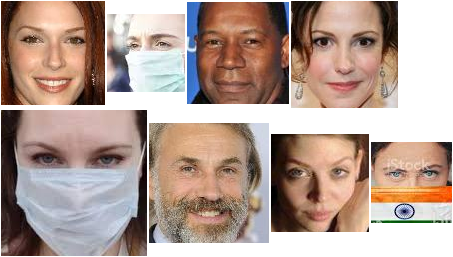

In [4]:
import torchvision
from torchvision.datasets import DatasetFolder
from torchvision import transforms
from torch.nn.functional import one_hot

n_classes = 2 # количество классов

# конвертация картинок
transform = transforms.Compose([
        transforms.Resize((64,64),), # масштабируем к единому размеру
        transforms.ToTensor(), # конвертируем в тензор  
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)), # нормализация
    ])

target_transform = ( # конвертируем номер класса в вектор скоров на выходе сети  (ONE HOT)
    lambda t: torch.squeeze( one_hot(torch.LongTensor([t]),num_classes=n_classes).type(torch.float32) )
)

# собираем учебный набор
folder_train = 'data/face-mask-dataset/Train'

ds_train = DatasetFolder(
    root=folder_train,
    loader=lambda path: Image.open(path),
    extensions=('.png'),
    transform = transform,
    target_transform= target_transform,
)


# собираем проверочный набор
folder_val = 'data/face-mask-dataset/Validation'

ds_val = DatasetFolder(
    root=folder_val,
    loader=lambda path: Image.open(path),
    extensions=('.png'),
    transform = transform,
    target_transform=target_transform,
)

In [5]:
# from torch.utils.data import DataLoader
# for x,t in DataLoader(ds, batch_size=128): break
# for x,t in DataLoader(ds_train, batch_size=12): break
# x.shape, t.shape    

# загружаем модель

In [6]:
from torchvision.models import vgg11

model = vgg11(weights=None)
display(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [7]:
# for x,t in DataLoader(ds_train, batch_size=2): break
# with torch.no_grad(): o = model(x)
# display(o)

In [8]:
# model.classifier[0].in_features

## заменяем классификатор под новый датасет

In [9]:
from torch import nn

n_featutes = model.classifier[0].in_features # размер слоя, который будем заменять

# новый классфикатор - двуслойный MLP с выходом Softmax
model.classifier = nn.Sequential(
        nn.Linear(n_featutes, 256), nn.ReLU(),
        nn.Linear(256, n_classes), nn.Softmax(dim=1)
    )

In [10]:
# for x,t in DataLoader(ds_train, batch_size=2): break
# with torch.no_grad(): o = model(x)
# display(o)

# обучаем модель

In [11]:
from torch import optim

criterion = torch.nn.CrossEntropyLoss() # ф-ция потери
optimizer = optim.Adam( model.parameters(), lr=1e-4 ) # метод оптимизации ф-ции потери

In [12]:
# используем GPU если есть
# device  = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device = 'cpu'

device(type='cuda', index=0)

In [13]:
# переключаем модель в режим обучения и загружаем модель на GPU
model.training = True
model = model.to(device)

In [14]:
from torch.utils.data import DataLoader

In [15]:
from sklearn.metrics import accuracy_score

# # будем мониторить погрешность модели по ходу обучения
def accuracy(ds,model=model):
    with torch.set_grad_enabled(False):
        for x,y in DataLoader(ds, batch_size=len(ds), shuffle=False):
            o = np.argmax( model(x.to(device)).cpu().numpy(),axis=1 )
    return accuracy_score(y.cpu().numpy()[:,1],o)

acc_history = [  accuracy(ds_val) ] # начальное значение погрешности

display(acc_history)

[0.5]

In [16]:
# считаем начальное значение ф-ции потери
with torch.set_grad_enabled(False):
    for x,y in DataLoader(ds_val, batch_size=len(ds_val), shuffle=False):
        loss = criterion( 
                y.to(device), 
                model(x.to(device))
            ).cpu().numpy().flatten()[0]

loss_history = [ loss ] 

display(loss_history)

[0.81361645]

## основной цикл обучения

In [17]:
%%time

from tqdm.auto import tqdm

n_epoch = 5 # количество эпох обучения
acc_min = .98 # порог допустимой погрешности модели

for i in tqdm(range(n_epoch)): 
    loss_batch=[]
    
    for x,y in DataLoader(ds_train, batch_size=512, shuffle=True): # получаем батч учебных примеров
        out = model(x.to(device)) # считаем выход модели
        loss = criterion( y.to(device),out ) # вычисляем значение ф-ции потери
        loss_batch.append(loss.item()) # дополняем историю изменения значений ф-ции потери
        optimizer.zero_grad() # очищаем предыдущее значение градиента
        loss.backward()  # вычисляем текущее значение градиента ф-ции потери
        optimizer.step() # корректируем параметры модели
                
    loss_history.append( np.mean(loss_batch) ) # дополняем историю изменения значений ф-ции потери
    acc_history.append( accuracy(ds_val,model=model) ) #значение погрешности
    if acc_history[-1] > acc_min: # проверяем достижение минимального порога погрешности модели
        print('step %i/%i: loss %.03f, acc threshold %.03f reached\n'%(i+1,n_epoch,loss_history[-1],acc_min))
        break

  0%|          | 0/5 [00:00<?, ?it/s]

CPU times: user 1min 43s, sys: 2.35 s, total: 1min 45s
Wall time: 3min 35s


## результаты обучения

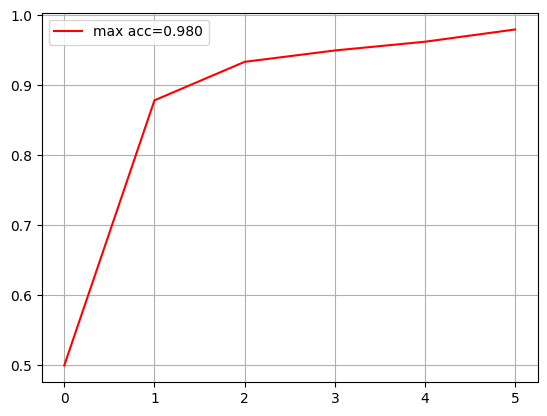

In [18]:
# история изменения значений погрешности модели
plt.plot(acc_history,label='max acc=%.3f'%(max(acc_history)),c='r')
plt.grid()
plt.legend()

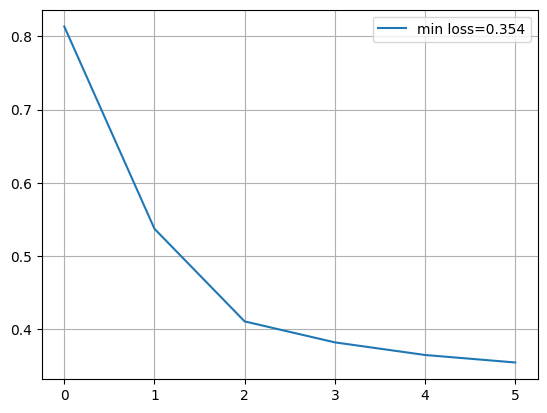

In [19]:
# история изменения значений ф-ции потери
plt.plot(loss_history,label='min loss=%.3f'%(min(loss_history)))
plt.grid()
plt.legend()

# тестируем модель

In [20]:
folder_test = 'data/face-mask-dataset/Test'

ds_test = DatasetFolder(
    root=folder_test,
    loader=lambda path: Image.open(path),
    extensions=('.png'),
    transform = transform,
    target_transform=target_transform,
)

display(len(ds_test))

992

In [21]:
# предииктим метки для тестового датасета
with torch.set_grad_enabled(False):
    for x,y in DataLoader(ds_test, batch_size=len(ds_test), shuffle=False):
        o = model( x.to(device) ).cpu().numpy()
o.shape        

(992, 2)

In [22]:
score = o[:,1]    
target = np.argmax(y,axis=1)

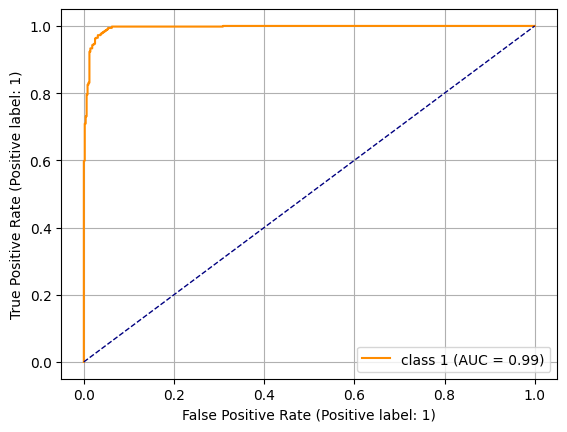

In [23]:
# рисуем ROC/AUC - зависимость точности и полноты при изменении порога скора
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions( target, score, name="class 1", color="darkorange", )
plt.plot([0,1],[0,1], color='navy', lw=1, linestyle='--')
plt.grid()

In [24]:
# определяем оптимальный порог скора 
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve( target, score )

#  максимальное количество True Positive при минимальном количестве False Positive
optimal_threshold = thresholds[ np.argmax( np.abs(tpr-fpr) )  ]
display(optimal_threshold)

0.54532963

In [25]:
# применяем оптимальный порог скора, предсказываем класс объектов
predicted = (score>optimal_threshold).astype(int)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       483
           1       0.97      0.97      0.97       509

    accuracy                           0.97       992
   macro avg       0.97      0.97      0.97       992
weighted avg       0.97      0.97      0.97       992



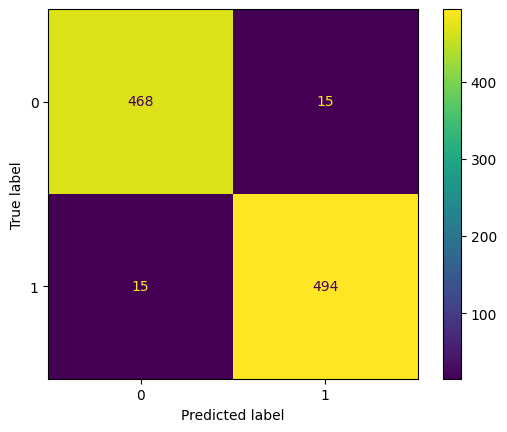

In [26]:
# оценка результатов тестирования

from sklearn.metrics import classification_report
print(classification_report(target,predicted))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(target, predicted), 
    #display_labels=classes
).plot()